In [1]:
# Cell 1: Imports

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.load_data import load_data
from src.preprocess import preprocess

sns.set_theme(style="whitegrid")

print("Imports successful!")

Imports successful!


In [2]:
# Cell 2: Load and preprocess

df_raw = load_data(filepath=project_root / "data" / "diabetic_data.csv")
df_clean = preprocess(df_raw)

Starting preprocessing...
  Input shape: (101766, 50)
  After dropping columns: (101766, 46)
  Validation passed: no missing values, all columns numeric.
  Final shape: (101766, 80)
  Missing values remaining: 0
Preprocessing complete!


In [3]:
# Cell 3: Verify the result

print(f"Raw shape:   {df_raw.shape}")
print(f"Clean shape: {df_clean.shape}")

target_exists = "readmitted_30d" in df_clean.columns
print(f"\nTarget variable preserved: {target_exists}")

if target_exists:
    positive_rate = df_clean["readmitted_30d"].mean() * 100
    print(f"Class balance: {positive_rate:.1f}% positive")

print(f"\nAny missing values left: {df_clean.isnull().sum().sum()}")

remaining_text_cols = df_clean.select_dtypes(include="object").columns.tolist()
print(f"Text columns remaining: {remaining_text_cols}")

print("\nFirst 5 rows:")
print(df_clean.head())

Raw shape:   (101766, 50)
Clean shape: (101766, 80)

Target variable preserved: True
Class balance: 11.2% positive

Any missing values left: 0
Text columns remaining: []

First 5 rows:
   gender  age  admission_type_id  discharge_disposition_id  \
0     0.0    5                  6                        25   
1     0.0   15                  1                         1   
2     0.0   25                  1                         1   
3     1.0   35                  1                         1   
4     1.0   45                  1                         1   

   admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  \
0                    1                 1                  41               0   
1                    7                 3                  59               0   
2                    7                 2                  11               5   
3                    7                 2                  44               1   
4                    7              

In [4]:
# Cell 4: Check medication encoding

med_cols = ["insulin", "metformin", "glipizide"]
existing_med_cols = [col for col in med_cols if col in df_clean.columns]

print("Sample medication columns should now contain only 0s and 1s:")
print(df_clean[existing_med_cols].value_counts().head(10))

if "insulin" in df_clean.columns:
    insulin_rate = df_clean["insulin"].mean() * 100
    print(f"\nInsulin prescribed in {insulin_rate:.1f}% of encounters")

for col in existing_med_cols:
    print(f"{col}: {sorted(df_clean[col].unique())}")

Sample medication columns should now contain only 0s and 1s:
insulin  metformin  glipizide
1        0          0            40024
0        0          0            32607
         1          0             8272
1        1          0             8177
0        0          1             4800
1        0          1             4347
         1          1             1835
0        1          1             1704
Name: count, dtype: int64

Insulin prescribed in 53.4% of encounters
insulin: [np.int64(0), np.int64(1)]
metformin: [np.int64(0), np.int64(1)]
glipizide: [np.int64(0), np.int64(1)]


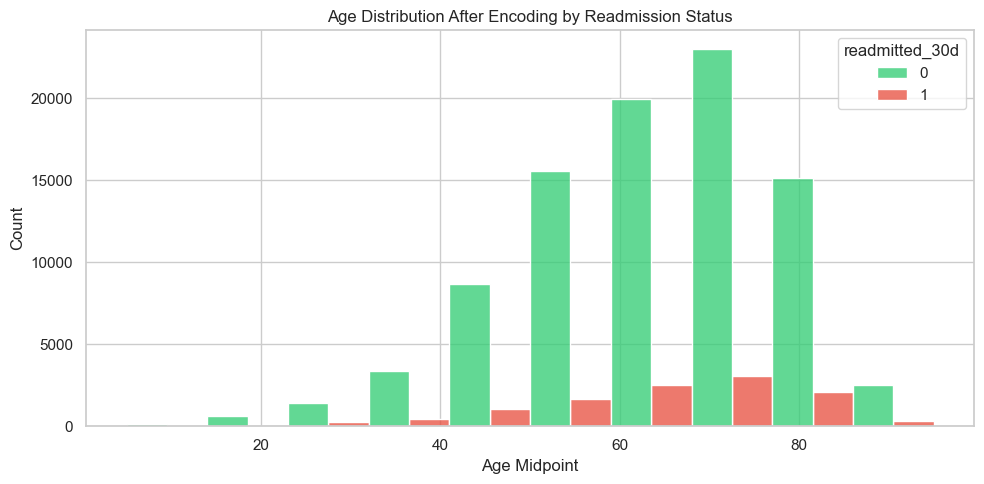

In [5]:
# Cell 5: Visualize the cleaned age distribution

reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="age",
    hue="readmitted_30d",
    bins=10,
    multiple="dodge",
    palette={0: "#2ecc71", 1: "#e74c3c"},
)

plt.title("Age Distribution After Encoding by Readmission Status")
plt.xlabel("Age Midpoint")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(reports_dir / "05_age_encoded.png", bbox_inches="tight", dpi=150)
plt.show()

In [6]:
# Cell 6: Save cleaned data for Phase 4

output_path = project_root / "data" / "diabetic_data_clean.csv"
output_path.parent.mkdir(exist_ok=True)

df_clean.to_csv(output_path, index=False)

print(f"Saved cleaned dataset to {output_path}")
print(f"Shape: {df_clean.shape}")

Saved cleaned dataset to /Users/matthewcarballo/Desktop/hospital-readmission-risk/data/diabetic_data_clean.csv
Shape: (101766, 80)
